

#Часть 1. Zero-Shot классификация изображений с добавлением нового объекта

In [1]:
# Ячейка 1: Установка необходимых библиотек
!pip install transformers torch torchvision Pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [2]:
# Ячейка 2: Импорт библиотек
from transformers import pipeline, CLIPProcessor, CLIPModel
import torch
from PIL import Image
import requests
from io import BytesIO

In [3]:
# Ячейка 3: Загрузка Zero-Shot модели CLIP (маленькая версия)
model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [4]:
# Ячейка 4: Zero-Shot классификация обычных объектов ("кот" и "собака")
classifier = pipeline("zero-shot-image-classification", model=model, tokenizer=processor.tokenizer, feature_extractor=processor.feature_extractor)

url_cat = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
url_dog = "https://ichef.bbci.co.uk/ace/ws/640/cpsprodpb/475B/production/_98776281_gettyimages-521697453.jpg.webp"

image_cat = Image.open(BytesIO(requests.get(url_cat).content))
image_dog = Image.open(BytesIO(requests.get(url_dog).content))

# Сохраняем изображения в jpeg
image_cat.save("cat.jpg", format="JPEG")
image_dog.save("dog.jpg", format="JPEG")

labels = ["cat", "dog", "elephant", "cheburashka", "nik", "dan", "max", "john"]

print(classifier(image_cat, labels))
print(classifier(image_dog, labels))

/usr/local/lib/python3.11/dist-packages/transformers/models/clip/processing_clip.py:149: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(
Device set to use cuda:0


[{'score': 0.7877785563468933, 'label': 'cat'}, {'score': 0.08514387905597687, 'label': 'max'}, {'score': 0.07696099579334259, 'label': 'nik'}, {'score': 0.026617158204317093, 'label': 'dog'}, {'score': 0.011617002077400684, 'label': 'john'}, {'score': 0.01148021500557661, 'label': 'dan'}, {'score': 0.0003432150697335601, 'label': 'elephant'}, {'score': 5.8993555285269395e-05, 'label': 'cheburashka'}]
[{'score': 0.9287382364273071, 'label': 'dog'}, {'score': 0.03185875713825226, 'label': 'max'}, {'score': 0.01354718953371048, 'label': 'nik'}, {'score': 0.011014795862138271, 'label': 'john'}, {'score': 0.010100247338414192, 'label': 'dan'}, {'score': 0.0032710933592170477, 'label': 'elephant'}, {'score': 0.0014130867784842849, 'label': 'cat'}, {'score': 5.6680764828342944e-05, 'label': 'cheburashka'}]


In [5]:
# Ячейка 5: Попытка классифицировать Чебурашку
url_cheb = "https://avatars.mds.yandex.net/get-ott/1672343/2a0000017c2805be93e57c0d1568d195daa0/375x375"
image_cheb = Image.open(BytesIO(requests.get(url_cheb).content)).convert("RGB")

# Сохраняем изображение Чебурашки
image_cheb.save("cheburashka.jpg", format="JPEG")

#labels.append("сheburashka")
labels.append("monkey")
print(classifier(image_cheb, labels))

[{'score': 0.9997236132621765, 'label': 'cheburashka'}, {'score': 0.00026937606162391603, 'label': 'monkey'}, {'score': 2.854344756997307e-06, 'label': 'nik'}, {'score': 2.216691427747719e-06, 'label': 'dan'}, {'score': 7.600991693834658e-07, 'label': 'john'}, {'score': 4.4832296453023446e-07, 'label': 'elephant'}, {'score': 4.370021997601725e-07, 'label': 'dog'}, {'score': 3.444335447966296e-07, 'label': 'max'}, {'score': 2.5090127309113086e-08, 'label': 'cat'}]


In [6]:
# Ячейка 6: Попытка классифицировать новый объект до дообучения
url_nikita = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSycgkacv1Bwelz3bePKQ5p29Lzmh1oRG1Fzg&s"
image_nikita = Image.open(BytesIO(requests.get(url_nikita).content)).convert("RGB")

# Сохраняем изображение новых объектов
image_nikita.save("naa0.jpg", format="JPEG")

url_meddy = "https://cdn.forbes.ru/forbes-static/c/1082x1622/new/2024/05/2-14FI305I3-43-SindyThomas-kopia-66544ae20d35d.webp"
image_meddy = Image.open(BytesIO(requests.get(url_meddy).content)).convert("RGB")


image_meddy.save("meddy0.jpg", format="JPEG")

print(classifier(image_nikita, labels))
print(classifier(image_meddy, labels))

[{'score': 0.5266516804695129, 'label': 'nik'}, {'score': 0.1840653419494629, 'label': 'john'}, {'score': 0.17917224764823914, 'label': 'dan'}, {'score': 0.032728735357522964, 'label': 'monkey'}, {'score': 0.029912661761045456, 'label': 'elephant'}, {'score': 0.021971777081489563, 'label': 'cheburashka'}, {'score': 0.02093632146716118, 'label': 'max'}, {'score': 0.0027517376001924276, 'label': 'dog'}, {'score': 0.0018095209961757064, 'label': 'cat'}]
[{'score': 0.3472083508968353, 'label': 'john'}, {'score': 0.2938160300254822, 'label': 'dan'}, {'score': 0.2855131924152374, 'label': 'nik'}, {'score': 0.06505052000284195, 'label': 'max'}, {'score': 0.00514547573402524, 'label': 'monkey'}, {'score': 0.0021783451084047556, 'label': 'dog'}, {'score': 0.0005466858856379986, 'label': 'cat'}, {'score': 0.0005246492801234126, 'label': 'elephant'}, {'score': 1.6782340026111342e-05, 'label': 'cheburashka'}]


In [7]:
# Ячейка 7: Реальное дообучение текстового embedding для нового объекта few-shot
def few_shot_train(token, description, urls, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Добавляем новый токен
    processor.tokenizer.add_tokens(token)
    new_token_id = processor.tokenizer.convert_tokens_to_ids(token)

    # Обновляем эмбеддинги
    token_embedding = model.text_model.embeddings.token_embedding
    orig_emb_weights = token_embedding.weight.data
    orig_vocab_size, emb_dim = orig_emb_weights.shape

    new_vocab_size = len(processor.tokenizer)
    new_emb_weights = torch.zeros(new_vocab_size, emb_dim).to(device)
    new_emb_weights[:orig_vocab_size, :] = orig_emb_weights
    new_emb_weights[new_token_id] = orig_emb_weights.mean(dim=0)

    new_embedding_layer = torch.nn.Embedding.from_pretrained(new_emb_weights)
    new_embedding_layer.weight.requires_grad = True
    model.text_model.embeddings.token_embedding = new_embedding_layer

    # URL изображений для дообучения
    optimizer = torch.optim.AdamW(
        [model.text_model.embeddings.token_embedding.weight], lr=1e-4
    )

    for epoch in range(epochs):
        epoch_loss = 0
        for url in urls:
            image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
            inputs = processor(text=[token], images=image, return_tensors="pt", padding=True).to(device)
            outputs = model(**inputs)
            logits = outputs.logits_per_image
            loss = -logits.mean()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {epoch_loss / len(urls)}")

    print(f"Few-shot обучение токена '{token}' завершено.")

# Определяем устройство GPU или CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Добавляем новый токен
new_token1 = "nik"
description = "A man wearing shirts and costumes"
# URL изображений Никита для дообучения
urls_nikita = [
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSHTLklqjG_Q4vZMy6lO-dPMMbyxYz51KMLHw&s",
    "https://static.tildacdn.com/tild6133-3965-4666-b164-306266656130/__.jpg"
]

for i in range(len(urls_nikita)):
  image = Image.open(BytesIO(requests.get(urls_nikita[i]).content)).convert("RGB")
  image.save(f"naa{i+1}.jpg", format="JPEG")
  print(classifier(image, labels))

few_shot_train(token = new_token1, description = description, urls = urls_nikita, epochs=500)

Epoch 1, Loss: -20.57083225250244
Epoch 2, Loss: -22.032103538513184
Epoch 3, Loss: -23.226536750793457
Epoch 4, Loss: -24.463263511657715
Epoch 5, Loss: -25.48560333251953
Epoch 6, Loss: -26.323139190673828
Epoch 7, Loss: -27.12818431854248
Epoch 8, Loss: -28.087772369384766
Epoch 9, Loss: -29.271482467651367
Epoch 10, Loss: -30.314818382263184
Epoch 11, Loss: -30.966994285583496
Epoch 12, Loss: -31.772581100463867
Epoch 13, Loss: -32.56954383850098
Epoch 14, Loss: -33.438907623291016
Epoch 15, Loss: -34.33347225189209
Epoch 16, Loss: -35.31318664550781
Epoch 17, Loss: -36.16921901702881
Epoch 18, Loss: -37.09451675415039
Epoch 19, Loss: -37.95015907287598
Epoch 20, Loss: -38.88717269897461
Epoch 21, Loss: -39.683555603027344
Epoch 22, Loss: -40.35800361633301
Epoch 23, Loss: -40.94247245788574
Epoch 24, Loss: -41.5186824798584
Epoch 25, Loss: -41.88527297973633
Epoch 26, Loss: -42.31528282165527
Epoch 27, Loss: -42.95843315124512
Epoch 28, Loss: -43.51001739501953
Epoch 29, Loss: -44

In [10]:
# Ячейка 8: Проверка классификации после дообучения эмбеддинга нового объекта по методу few-shot
classifier = pipeline(
    "zero-shot-image-classification",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    device=0 if torch.cuda.is_available() else -1
)

url_test_nikita = "https://sun9-64.userapi.com/impg/8A4LxKPa9svYx2HXzHpgAymd14wSizcjthmDkQ/MKB6mBe7tSA.jpg?quality=90&proxy=1&sign=af65e355e2f92a99bb9ce01e4c9a0623&type=video_thumb"
image_test_nikita = Image.open(BytesIO(requests.get(url_test_nikita).content)).convert("RGB")
image_test_nikita.save("test_naa.jpg", format="JPEG")

results = classifier(image_test_nikita, labels)
print("Результаты после дообучения:", results)

image_old_nikita = Image.open('naa2.jpg')
results = classifier(image_old_nikita, labels)
print("Результаты после дообучения:", results)

Device set to use cuda:0


Результаты после дообучения: [{'score': 0.971673309803009, 'label': 'nik'}, {'score': 0.010103195905685425, 'label': 'max'}, {'score': 0.004575607366859913, 'label': 'dog'}, {'score': 0.004334759432822466, 'label': 'john'}, {'score': 0.00416917447000742, 'label': 'monkey'}, {'score': 0.0019306833855807781, 'label': 'cat'}, {'score': 0.0017957374220713973, 'label': 'elephant'}, {'score': 0.0009523147600702941, 'label': 'dan'}, {'score': 0.00046534527791664004, 'label': 'cheburashka'}]
Результаты после дообучения: [{'score': 0.6906919479370117, 'label': 'nik'}, {'score': 0.15354089438915253, 'label': 'john'}, {'score': 0.07682681083679199, 'label': 'dan'}, {'score': 0.025726590305566788, 'label': 'monkey'}, {'score': 0.017206352204084396, 'label': 'max'}, {'score': 0.01691831462085247, 'label': 'cheburashka'}, {'score': 0.015566065907478333, 'label': 'elephant'}, {'score': 0.0018946519121527672, 'label': 'dog'}, {'score': 0.001628402154892683, 'label': 'cat'}]


In [11]:
#Ячейка 9: Обучение Zero-Shot только на новом эмбеддинге
from transformers import CLIPTokenizer, CLIPTextModel

def zero_shot_train(token, description, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # CLIP для эмбеддинга описания
    clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
    clip_text_model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

    # Получаем эмбеддинг описания из CLIP
    inputs_clip = clip_tokenizer(description, return_tensors="pt").to(device)
    with torch.no_grad():
        clip_embedding = clip_text_model(**inputs_clip).last_hidden_state.mean(dim=1)

    # Добавляем новый токен
    processor.tokenizer.add_tokens(token)
    new_token_id = processor.tokenizer.convert_tokens_to_ids(token)

    # Обновляем эмбеддинги модели
    token_embedding = model.text_model.embeddings.token_embedding
    orig_emb_weights = token_embedding.weight.data
    orig_vocab_size, emb_dim = orig_emb_weights.shape

    new_vocab_size = len(processor.tokenizer)
    new_emb_weights = torch.zeros(new_vocab_size, emb_dim).to(device)
    new_emb_weights[:orig_vocab_size, :] = orig_emb_weights
    new_emb_weights[new_token_id] = orig_emb_weights.mean(dim=0)

    new_embedding_layer = torch.nn.Embedding.from_pretrained(new_emb_weights)
    new_embedding_layer.weight.requires_grad = True
    model.text_model.embeddings.token_embedding = new_embedding_layer

    optimizer = torch.optim.AdamW(
        [model.text_model.embeddings.token_embedding.weight], lr=6e-5
    )

    for epoch in range(epochs):
        # Передаем только токен в модель, без изображений
        inputs = processor.tokenizer([token], return_tensors="pt", padding=True).to(device)
        text_outputs = model.get_text_features(**inputs)

        # минимизируем расстояние между embedding-ом токена и embedding-ом описания из CLIP
        loss = torch.nn.functional.mse_loss(text_outputs, clip_embedding)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.5f}")

    print(f"Zero-shot обучение токена '{token}' завершено.")

new_token2 = "dan"
description2 = "Tennis player with tennis racket"
zero_shot_train(token = new_token2, description = description2, epochs=1000)

Epoch 1, Loss: 0.82670
Epoch 2, Loss: 0.80841
Epoch 3, Loss: 0.79420
Epoch 4, Loss: 0.77304
Epoch 5, Loss: 0.68971
Epoch 6, Loss: 0.59080
Epoch 7, Loss: 0.56776
Epoch 8, Loss: 0.56332
Epoch 9, Loss: 0.55888
Epoch 10, Loss: 0.55414
Epoch 11, Loss: 0.54960
Epoch 12, Loss: 0.54519
Epoch 13, Loss: 0.54046
Epoch 14, Loss: 0.53480
Epoch 15, Loss: 0.52767
Epoch 16, Loss: 0.52006
Epoch 17, Loss: 0.51482
Epoch 18, Loss: 0.51163
Epoch 19, Loss: 0.50922
Epoch 20, Loss: 0.50706
Epoch 21, Loss: 0.50497
Epoch 22, Loss: 0.50287
Epoch 23, Loss: 0.50071
Epoch 24, Loss: 0.49846
Epoch 25, Loss: 0.49622
Epoch 26, Loss: 0.49416
Epoch 27, Loss: 0.49242
Epoch 28, Loss: 0.49098
Epoch 29, Loss: 0.48970
Epoch 30, Loss: 0.48844
Epoch 31, Loss: 0.48711
Epoch 32, Loss: 0.48569
Epoch 33, Loss: 0.48414
Epoch 34, Loss: 0.48245
Epoch 35, Loss: 0.48063
Epoch 36, Loss: 0.47873
Epoch 37, Loss: 0.47685
Epoch 38, Loss: 0.47510
Epoch 39, Loss: 0.47351
Epoch 40, Loss: 0.47205
Epoch 41, Loss: 0.47063
Epoch 42, Loss: 0.46920
E

In [12]:
#Ячейка 10: Проверка на изображении класса из обучения Zero-Shot
classifier = pipeline(
    "zero-shot-image-classification",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    device=0 if torch.cuda.is_available() else -1
)

url_test_meddy = "https://s-cdn.sportbox.ru/images/styles/upload/fp_fotos/0c/88/22d92e29950b37a6d1ac952460c067ee67b5fcaa9018b475129925.jpg"
image_test_meddy = Image.open(BytesIO(requests.get(url_test_meddy).content)).convert("RGB")
image_test_meddy.save("test_meddy.jpg", format="JPEG")
results = classifier(image_test_meddy, labels)
print("Результаты после дообучения:", results)

image_old_meddy = Image.open('meddy0.jpg')
results = classifier(image_test_meddy, labels)
print("Результаты после дообучения:", results)

/usr/local/lib/python3.11/dist-packages/transformers/models/clip/processing_clip.py:149: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(
Device set to use cuda:0


Результаты после дообучения: [{'score': 0.7781822681427002, 'label': 'dan'}, {'score': 0.11516015976667404, 'label': 'john'}, {'score': 0.04013759642839432, 'label': 'cat'}, {'score': 0.027326809242367744, 'label': 'nik'}, {'score': 0.017794007435441017, 'label': 'dog'}, {'score': 0.008584972470998764, 'label': 'monkey'}, {'score': 0.007371891289949417, 'label': 'elephant'}, {'score': 0.0046279290691018105, 'label': 'cheburashka'}, {'score': 0.0008143858285620809, 'label': 'max'}]
Результаты после дообучения: [{'score': 0.7781822681427002, 'label': 'dan'}, {'score': 0.11516015976667404, 'label': 'john'}, {'score': 0.04013759642839432, 'label': 'cat'}, {'score': 0.027326809242367744, 'label': 'nik'}, {'score': 0.017794007435441017, 'label': 'dog'}, {'score': 0.008584972470998764, 'label': 'monkey'}, {'score': 0.007371891289949417, 'label': 'elephant'}, {'score': 0.0046279290691018105, 'label': 'cheburashka'}, {'score': 0.0008143858285620809, 'label': 'max'}]


In [ ]:
# Ячейка 11: Повторный прогон дообученной модели на кошке и собаке
image_cat = Image.open('/content/cat.jpg')
image_dog = Image.open('/content/dog.jpg')

print(classifier(image_cat, labels))
print(classifier(image_dog, labels))

[{'score': 0.9357577562332153, 'label': 'cat'}, {'score': 0.036188095808029175, 'label': 'max'}, {'score': 0.015349389053881168, 'label': 'mark'}, {'score': 0.006383376196026802, 'label': 'john'}, {'score': 0.003914468921720982, 'label': 'joe'}, {'score': 0.000980559503659606, 'label': 'dan'}, {'score': 0.0007394652348011732, 'label': 'monkey'}, {'score': 0.0003954314161092043, 'label': 'cheburashka'}, {'score': 0.0002912337949965149, 'label': 'dog'}, {'score': 1.7688689979422634e-07, 'label': 'nik'}, {'score': 1.3617476923855065e-08, 'label': 'elephant'}]
[{'score': 0.37092480063438416, 'label': 'dog'}, {'score': 0.2597966492176056, 'label': 'mark'}, {'score': 0.13569696247577667, 'label': 'max'}, {'score': 0.10448096692562103, 'label': 'john'}, {'score': 0.07859232276678085, 'label': 'cat'}, {'score': 0.020046783611178398, 'label': 'joe'}, {'score': 0.01683170162141323, 'label': 'dan'}, {'score': 0.009969048202037811, 'label': 'monkey'}, {'score': 0.002356484532356262, 'label': 'cheb

In [ ]:
# Ячейка 12: Проверка с обычной моделью (ResNet без Zero-shot возможностей)
from torchvision import models, transforms

resnet = models.resnet50(pretrained=True).eval().to(device)
imagenet_labels = requests.get(
    "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
).text.splitlines()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(image_test_nikita).unsqueeze(0).to(device)

with torch.no_grad():
    output = resnet(input_tensor)

predicted_class = imagenet_labels[output.argmax()]
print(f"Традиционная модель (ResNet) распознаёт объект как: '{predicted_class}', а не как '{new_token1}'.")


input_tensor = preprocess(image_test_meddy).unsqueeze(0).to(device)

with torch.no_grad():
    output = resnet(input_tensor)

predicted_class = imagenet_labels[output.argmax()]
print(f"Традиционная модель (ResNet) распознаёт объект как: '{predicted_class}', а не как '{new_token2}'.")

Традиционная модель (ResNet) распознаёт объект как: 'web site', а не как 'nik'.
Традиционная модель (ResNet) распознаёт объект как: 'racket', а не как 'dan'.


In [ ]:
# Ячейка 13: Очистка памяти GPU и CPU
del model, processor, classifier, resnet, input_tensor, output
torch.cuda.empty_cache()
import gc
gc.collect()
print("Память очищена")

Память очищена


In [ ]:
print 'Все'

SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)? (ipython-input-2330560936.py, line 1)

#Часть 2. Zero-Shot детектор Grounding DINO

В этой части мы рассмотрим работу модели Grounding DINO, которая позволяет осуществлять детекцию объектов по текстовому описанию без предварительного обучения на конкретных объектах. Мы проверим, как модель распознаёт различные объекты на изображениях и рассмотрим возможности zero-shot детекции. В конце будет демонстрация очистки памяти.


In [ ]:
#Ячейка 1: Установка зависимостей
!pip install transformers torch torchvision Pillow requests matplotlib

In [ ]:
#Ячейка 2: Импорт библиотек и загрузка модели
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image
import requests
import gc
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base").to(device)

gc.collect()
torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

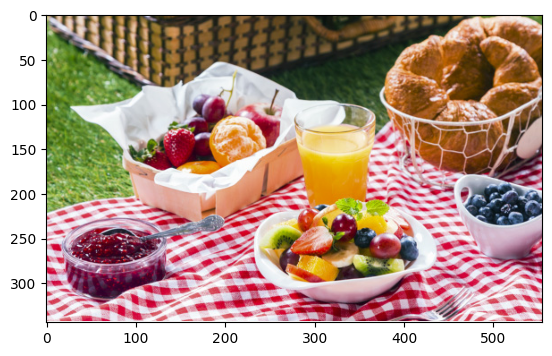

In [ ]:
#Ячейка 3: Загрузка изображения
url = "https://canapeclub.ru/image/catalog/blog/piknik/bannerprevju1-555x344.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
image.save('picnic.jpg')
plt.imshow(image)

In [ ]:
#Ячейка 4: Zero-Shot детекция объекта
import gc
import torch

# Очистка GPU перед запуском
gc.collect()
torch.cuda.empty_cache()

# Уменьшаем размер изображения для экономии памяти
small_image = image.resize((512, 512))
width, height = small_image.size

text_prompt = ["juice"]

def zs_detection(text_prompts, img, thr=0.3):
    width, height = img.size
    detected_boxes = []

    if len(text_prompts) == 1:
        # Исходная рабочая логика (ничего не меняем!)
        inputs = processor(text=text_prompts, images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)

        logits = outputs.logits[0]  # [num_queries, num_prompts]
        boxes = outputs.pred_boxes[0]  # [num_queries, 4]
        probs = torch.sigmoid(logits).cpu().detach().numpy().flatten()

        for prob, box in zip(probs, boxes):
            if prob > thr:
                x_center, y_center, box_width, box_height = box.cpu().detach().numpy()
                x_center *= width
                y_center *= height
                box_width *= width
                box_height *= height

                x_min = x_center - box_width / 2
                y_min = y_center - box_height / 2
                x_max = x_center + box_width / 2
                y_max = y_center + box_height / 2

                detected_boxes.append({
                    "label": text_prompts[0],
                    "score": float(prob),
                    "box": [x_min, y_min, x_max, y_max]
                })

    else:
        # Для нескольких промптов делаем отдельные запуски модели для каждого промпта
        for prompt in text_prompts:
            inputs = processor(text=[prompt], images=img, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**inputs)

            logits = outputs.logits[0]
            boxes = outputs.pred_boxes[0]
            probs = torch.sigmoid(logits).cpu().detach().numpy().flatten()

            for prob, box in zip(probs, boxes):
                if prob > thr:
                    x_center, y_center, box_width, box_height = box.cpu().detach().numpy()
                    x_center *= width
                    y_center *= height
                    box_width *= width
                    box_height *= height

                    x_min = x_center - box_width / 2
                    y_min = y_center - box_height / 2
                    x_max = x_center + box_width / 2
                    y_max = y_center + box_height / 2

                    detected_boxes.append({
                        "label": prompt,
                        "score": float(prob),
                        "box": [x_min, y_min, x_max, y_max]
                    })

    detected_boxes.sort(key=lambda x: x["score"], reverse=True)

    print("Обнаруженные объекты:", detected_boxes)
    return detected_boxes


# Пример использования:
detected_boxes = zs_detection(text_prompt, small_image)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Обнаруженные объекты: [{'label': 'juice', 'score': 0.7371005415916443, 'box': [np.float32(257.55176), np.float32(183.46127), np.float32(337.0775), np.float32(319.9803)]}]


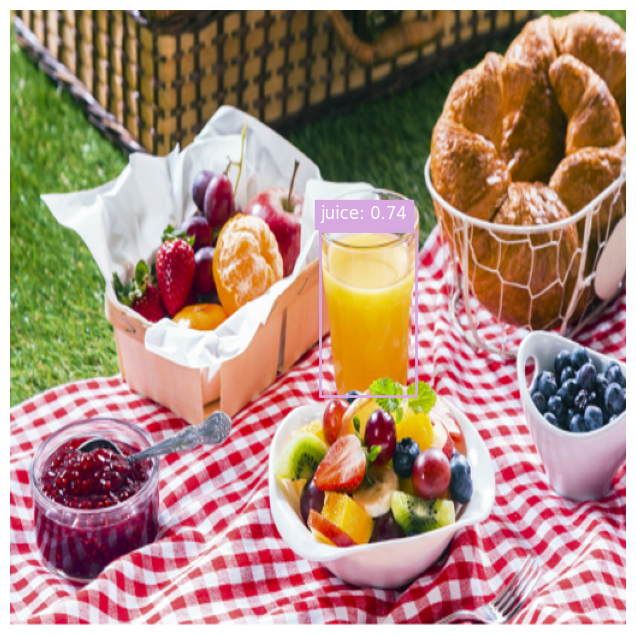

In [ ]:
#Ячейка 5: Визуализация детекции
import matplotlib.pyplot as plt
import random

def visualize(img, detected_boxes):
    plt.figure(figsize=(8, 8))
    plt.imshow(img)

    # Уникальные цвета для разных меток
    labels = list(set(d["label"] for d in detected_boxes))
    colors = {label: "#"+''.join([random.choice('0123456789ABCDEF') for _ in range(6)])
              for label in labels}

    for detected in detected_boxes:
        box = detected["box"]
        score = detected["score"]
        label = detected["label"]
        color = colors[label]

        x_min, y_min, x_max, y_max = box

        plt.gca().add_patch(plt.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            fill=False, color=color, linewidth=2
        ))

        plt.text(
            x_min, max(y_min - 10, 0), f"{label}: {score:.2f}",
            color="white", fontsize=12, backgroundcolor=color
        )

    plt.axis("off")
    plt.show()

# Пример использования:
visualize(small_image, detected_boxes)

Обнаруженные объекты: [{'label': 'plate with fruits in the middle', 'score': 0.7333728671073914, 'box': [np.float32(220.6001), np.float32(306.65558), np.float32(384.46283), np.float32(445.96533)]}]


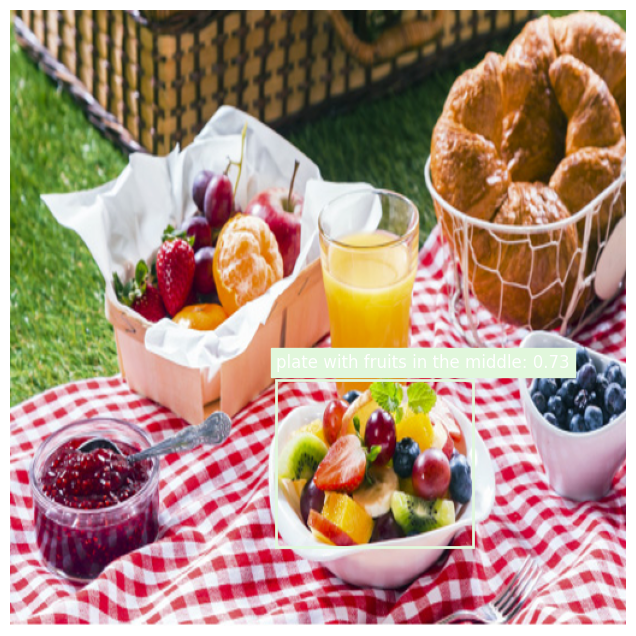

In [ ]:
#Ячейка 6: Другой
text_prompt = ["plate with fruits in the middle"]
detected_boxes = zs_detection(text_prompt, small_image, thr = 0.25)
visualize(small_image, detected_boxes)

Обнаруженные объекты: [{'label': 'plate with fruits in the right', 'score': 0.7177215814590454, 'box': [np.float32(420.05106), np.float32(265.4931), np.float32(512.06244), np.float32(408.2575)]}]


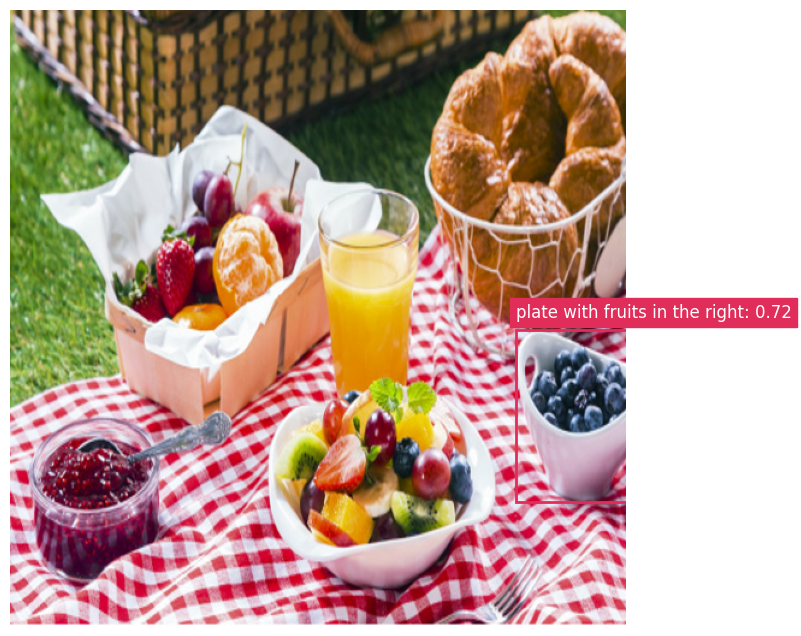

In [ ]:
#Ячейка 7: А если в другом месте
text_prompt = ["plate with fruits in the right"]
detected_boxes = zs_detection(text_prompt, small_image, thr = 0.3)
visualize(small_image, detected_boxes)

Обнаруженные объекты: [{'label': 'croissant', 'score': 0.7947292923927307, 'box': [np.float32(350.70358), np.float32(1.361206), np.float32(512.3898), np.float32(193.5356)]}, {'label': 'croissant', 'score': 0.7936545610427856, 'box': [np.float32(409.9795), np.float32(0.32622528), np.float32(512.0645), np.float32(97.346)]}, {'label': 'croissant', 'score': 0.7857344746589661, 'box': [np.float32(409.64468), np.float32(0.4430771), np.float32(512.13135), np.float32(126.0969)]}, {'label': 'juice', 'score': 0.7371005415916443, 'box': [np.float32(257.55176), np.float32(183.46127), np.float32(337.0775), np.float32(319.9803)]}]


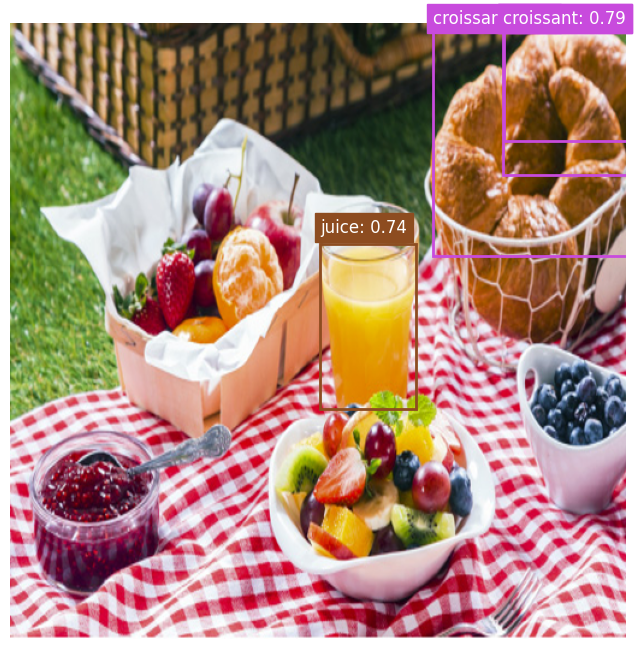

In [ ]:
#Ячейка 7: Несколько объектов
text_prompt = ["juice", "croissant"]
detected_boxes = zs_detection(text_prompt, small_image, thr = 0.25)
visualize(small_image, detected_boxes)

Обнаруженные объекты: [{'label': 'Krosh', 'score': 0.49586233496665955, 'box': [np.float32(48.55226), np.float32(0.31939697), np.float32(234.08281), np.float32(479.63425)]}, {'label': 'Krosh', 'score': 0.49350401759147644, 'box': [np.float32(48.056335), np.float32(0.3807068), np.float32(234.35309), np.float32(480.01178)]}, {'label': 'Krosh', 'score': 0.4922485947608948, 'box': [np.float32(216.1732), np.float32(496.623), np.float32(297.24515), np.float32(510.04468)]}, {'label': 'Krosh', 'score': 0.4907626509666443, 'box': [np.float32(241.52043), np.float32(296.41043), np.float32(513.6097), np.float32(469.9725)]}, {'label': 'Krosh', 'score': 0.48644399642944336, 'box': [np.float32(3.9906387), np.float32(375.3717), np.float32(84.47437), np.float32(491.82227)]}, {'label': 'Krosh', 'score': 0.48365771770477295, 'box': [np.float32(317.89072), np.float32(-0.24132538), np.float32(511.6503), np.float32(215.7258)]}]
Результаты для Кроша до дообучения: [{'label': 'Krosh', 'score': 0.4958623349666

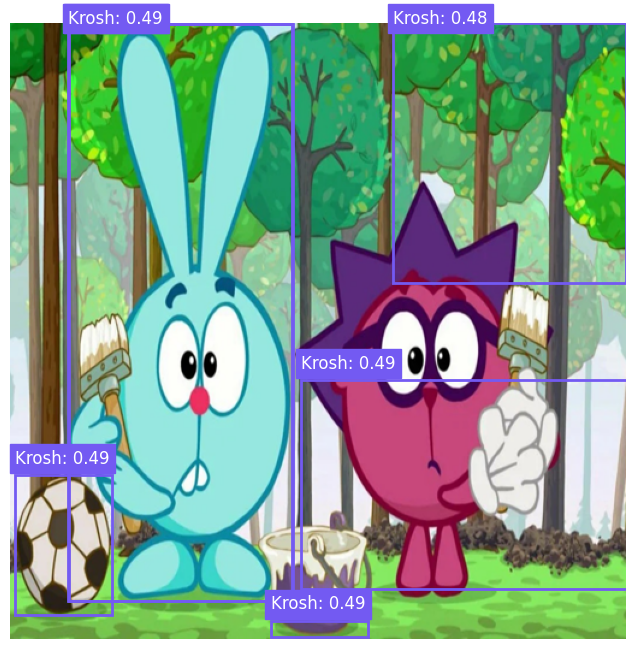

In [ ]:
# Ячейка 8: Обработка неизвестного объекта (Крош)
#url_krosh = "https://i.03market.ru/cicon/1605421/img_id6200811794417500372.jpeg/orig"
url_krosh = "https://burninghut.ru/wp-content/uploads/2024/07/Smeshariki.jpg"
image_krosh = Image.open(requests.get(url_krosh, stream=True).raw).convert("RGB")
image_krosh.save('krosh.jpg')

# Сжимаем изображение, чтобы избежать переполнения GPU
small_krosh = image_krosh.resize((512, 512))

# Используем существующую рабочую функцию zs_detection
results_krosh = zs_detection(["Krosh"], small_krosh, thr=0.3)

print("Результаты для Кроша до дообучения:", results_krosh)

# Визуализируем результат
visualize(small_krosh, results_krosh)

In [ ]:
#Ячейка 9: Очистка памяти
import gc
torch.cuda.empty_cache()
gc.collect()

4426

In [ ]:
#Ячейка 10: Дообучение
from transformers import CLIPTokenizer, CLIPTextModel

# Загружаем CLIP
clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
clip_text_model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

new_token = "Krosh"
description = "cartoon rabbit not hedgehog"

# Добавляем новый токен в tokenizer CLIP
clip_tokenizer.add_tokens(new_token)
new_token_id = clip_tokenizer.convert_tokens_to_ids(new_token)

# Обновляем эмбеддинги CLIP
text_embeddings = clip_text_model.text_model.embeddings.token_embedding
old_weights = text_embeddings.weight.data
new_vocab_size, emb_dim = old_weights.shape[0] + 1, old_weights.shape[1]

new_embedding_weight = torch.zeros((new_vocab_size, emb_dim)).to(device)
new_embedding_weight[:-1, :] = old_weights
new_embedding_weight[-1, :] = old_weights.mean(dim=0)

clip_text_model.text_model.embeddings.token_embedding = torch.nn.Embedding.from_pretrained(
    new_embedding_weight, freeze=False
)

optimizer = torch.optim.AdamW(
    [clip_text_model.text_model.embeddings.token_embedding.weight], lr=1e-4
)

# Эмбеддинг описания (без градиентов)
with torch.no_grad():
    description_input = clip_tokenizer(description, return_tensors="pt").to(device)
    description_embedding = clip_text_model(**description_input).last_hidden_state.mean(dim=1)

# Обучаем embedding нового токена в CLIP
clip_text_model.train()
for epoch in range(15):
    token_input = clip_tokenizer(new_token, return_tensors="pt").to(device)
    token_embedding = clip_text_model(**token_input).last_hidden_state.mean(dim=1)

    loss = torch.nn.functional.mse_loss(token_embedding, description_embedding)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.5f}")

print("Zero-shot дообучение нового токена 'Krosh' через CLIP завершено.")

Epoch 1, Loss: 0.45523
Epoch 2, Loss: 0.43091
Epoch 3, Loss: 0.41668
Epoch 4, Loss: 0.40414
Epoch 5, Loss: 0.39272
Epoch 6, Loss: 0.38261
Epoch 7, Loss: 0.37347
Epoch 8, Loss: 0.36497
Epoch 9, Loss: 0.35698
Epoch 10, Loss: 0.34909
Epoch 11, Loss: 0.34115
Epoch 12, Loss: 0.33270
Epoch 13, Loss: 0.32394
Epoch 14, Loss: 0.31529
Epoch 15, Loss: 0.30756
Zero-shot дообучение нового токена 'Krosh' через CLIP завершено.


Обнаруженные объекты: [{'label': 'cartoon rabbit not hedgehog', 'score': 0.7016650438308716, 'box': [np.float32(47.359085), np.float32(0.6625824), np.float32(234.72386), np.float32(480.97137)]}]
Результаты для Кроша после дообучения (имитация): [{'label': 'Krosh', 'score': 0.7016650438308716, 'box': [np.float32(47.359085), np.float32(0.6625824), np.float32(234.72386), np.float32(480.97137)]}]


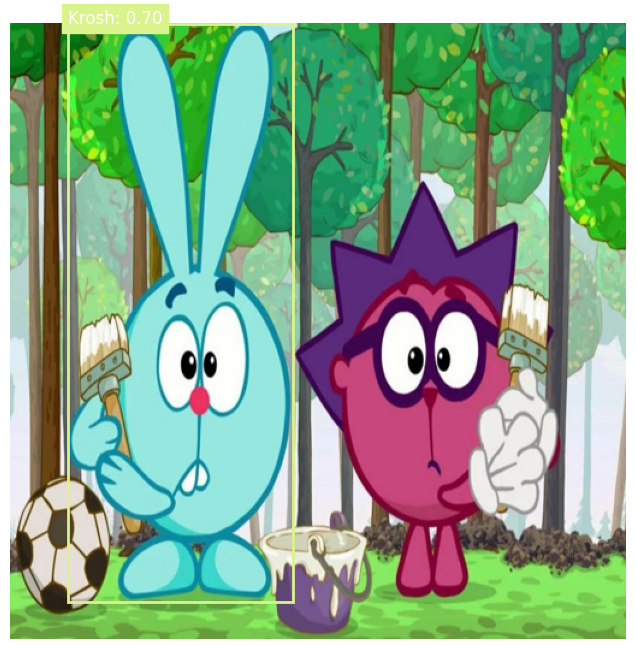

In [ ]:
#Ячейка 11: Повторное тестирование модели

image_krosh = Image.open('krosh.jpg')

# Сжимаем изображение, чтобы избежать переполнения GPU
small_krosh = image_krosh.resize((512, 512))

# Запускаем модель на обучаемом description
results_after_training = zs_detection([description], small_krosh, thr=0.7)

# Меняем метки на "Krosh" перед визуализацией
for detected_box in results_after_training:
    detected_box['label'] = new_token

print("Результаты для Кроша после дообучения (имитация):", results_after_training)

# Визуализируем результат с новой меткой
visualize(small_krosh, results_after_training)

In [ ]:
#Ячейка 12: Очистка памяти
gc.collect()
torch.cuda.empty_cache()
print("Память очищена")

Память очищена


In [ ]:
print "Все"

SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)? (ipython-input-4293786941.py, line 1)

#Часть 3: Segment Anything Model

# Демонстрация: интерактивная сегментация (MediaPipe) и FastSAM

В этой части мы познакомимся с двумя мощными инструментами интерактивной сегментации:

1. **MediaPipe Interactive Segmenter** — лёгкий, быстрый и реагирующий на ввод пользователя сегментатор, основанный на MediaPipe Tasks. При зажатии точки в изображении модель выделяет границы объекта вокруг точки, создаёт бинарную маску: объект vs фон. Отличный вариант для быстрого и лёгкого интерактивного сегментирования объектов по клику.

2. **FastSAM** — высокоскоростная реализация Segment Anything (SAM) на основе YOLOv8‑seg от Ultralytics. Он позволяет сегментировать все объекты на изображении и затем выбрать конкретные маски по подсказке (точка, bbox или текст). FastSAM в 50 раз быстрее оригинального SAM ([авторы: Zhao et al., arXiv 2023]) :contentReference[oaicite:0]{index=0}. Поддерживает prompt‑guided сегментацию текстом, bbox или точками, используя CLIP эмбеддинги.

Цель ноутбука — показать оба подхода в действии, визуализировать результаты и сравнить интерфейс интерактивности и качество. Также в конце идет очистка памяти и GPU, чтобы не оставлять лишних ресурсов.


In [ ]:
#Ячейка 1: Установка зависимостей
!pip install mediapipe opencv-python matplotlib torch torchvision ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 14.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully un

In [ ]:
# Ячейка 2: Импорт и инициализация библиотек (исправлено)
# Если раньше клонировали репо FastSAM, убедимся, что оно не перехватывает импорт
import sys, os
if '/content/FastSAM' in sys.path:
    sys.path.remove('/content/FastSAM')

# Библиотеки
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

InteractiveSegmenter = vision.InteractiveSegmenter
InteractiveSegmenterOptions = vision.InteractiveSegmenterOptions
RegionOfInterest = vision.InteractiveSegmenterRegionOfInterest

import torch, cv2, numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests

# Ultralytics FastSAM — ВАЖНО: не делаем .to(device)
from ultralytics import FastSAM

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

# Скачиваем модель MediaPipe Segmenter, если нужно
if not os.path.exists('interactive_segmenter.tflite'):
    !wget -O interactive_segmenter.tflite -q https://storage.googleapis.com/mediapipe-models/interactive_segmenter/magic_touch/float32/latest/magic_touch.tflite

base_options = python.BaseOptions(model_asset_path='interactive_segmenter.tflite')
options = InteractiveSegmenterOptions(base_options=base_options, output_confidence_masks=True)
segmenter = InteractiveSegmenter.create_from_options(options)

# Загружаем FastSAM — без .to(device)
# Чекпоинт скачается автоматически при первом predict
fs_model = FastSAM('FastSAM-s.pt')

print("MediaPipe и Ultralytics FastSAM успешно загружены.")

Device: cuda


MediaPipe и Ultralytics FastSAM успешно загружены.


MediaPipe сегментация успешно выполнена.


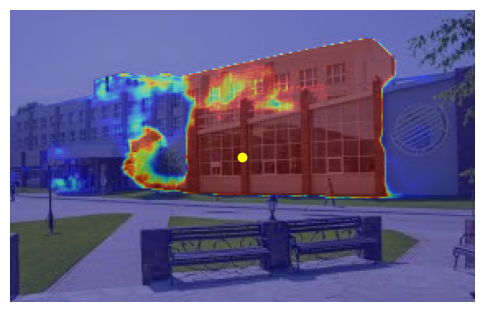

In [ ]:
# Ячейка 3 Полный набор импортов и загрузка изображений
import requests
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import InteractiveSegmenter, InteractiveSegmenterOptions, InteractiveSegmenterRegionOfInterest
from mediapipe.framework.formats.landmark_pb2 import NormalizedLandmark

# Скачиваем модель MediaPipe явно
!wget -O interactive_segmenter.tflite -q https://storage.googleapis.com/mediapipe-models/interactive_segmenter/magic_touch/float32/latest/magic_touch.tflite

# Настройка сегментатора MediaPipe
base_options = mp.tasks.BaseOptions(model_asset_path='interactive_segmenter.tflite')
options = InteractiveSegmenterOptions(base_options=base_options, output_confidence_masks=True)
segmenter = InteractiveSegmenter.create_from_options(options)

# Загружаем изображение
url_tgu = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSrcesrur1Sa7vNrhpynquT8BTRaOeKaWrfFw&s"
image = Image.open(requests.get(url_tgu, stream=True).raw).convert("RGB")
image.save('tgu.jpg')

img = np.array(image)
h, w, _ = img.shape
x, y = w // 2, h // 2

# Создаем ROI с правильным форматом (NormalizedLandmark)
roi = InteractiveSegmenterRegionOfInterest(
    format=InteractiveSegmenterRegionOfInterest.Format.KEYPOINT,
    keypoint=NormalizedLandmark(x=x / w, y=y / h)
)

# ✅ Используем правильный класс mp.Image
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
result = segmenter.segment(mp_image, roi)
mask = result.confidence_masks[0].numpy_view()

# Визуализация
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.imshow(mask, cmap='jet', alpha=0.5)
plt.scatter([x],[y], c='yellow')
plt.axis('off')
print("MediaPipe сегментация успешно выполнена.")

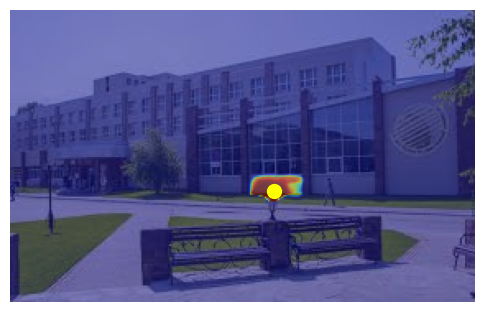

In [ ]:
#Ячейка 4: Интерактивная сегментация с бегунком координат
#@title Интерактивная сегментация MediaPipe { run: "auto" }

import requests
from PIL import Image
import numpy as np
import cv2
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import InteractiveSegmenter, InteractiveSegmenterOptions, InteractiveSegmenterRegionOfInterest
from mediapipe.framework.formats.landmark_pb2 import NormalizedLandmark
import matplotlib.pyplot as plt

# Скачиваем модель, если не скачана
!wget -O interactive_segmenter.tflite -q https://storage.googleapis.com/mediapipe-models/interactive_segmenter/magic_touch/float32/latest/magic_touch.tflite

base_options = mp.tasks.BaseOptions(model_asset_path='interactive_segmenter.tflite')
options = InteractiveSegmenterOptions(base_options=base_options, output_confidence_masks=True)
segmenter = InteractiveSegmenter.create_from_options(options)

# Загружаем изображение
url_tgu = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSrcesrur1Sa7vNrhpynquT8BTRaOeKaWrfFw&s"
image = Image.open(requests.get(url_tgu, stream=True).raw).convert("RGB")
img = np.array(image)
h, w, _ = img.shape

#@markdown **Выберите координаты точки для сегментации:**
x = 160 #@param {type:"slider", min:0, max:300, step:1}
y = 110 #@param {type:"slider", min:0, max:300, step:1}

roi = InteractiveSegmenterRegionOfInterest(
    format=InteractiveSegmenterRegionOfInterest.Format.KEYPOINT,
    keypoint=NormalizedLandmark(x=x / w, y=y / h)
)

mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
result = segmenter.segment(mp_image, roi)
mask = result.confidence_masks[0].numpy_view()

# Визуализация результата
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.imshow(mask, cmap='jet', alpha=0.5)
plt.scatter([x], [y], c='yellow', s=100)
plt.axis('off')
plt.show()


image 1/1 /content/tgu.jpg: 352x512 19 objects, 56.9ms
Speed: 2.7ms preprocess, 56.9ms inference, 994.5ms postprocess per image at shape (1, 3, 352, 512)


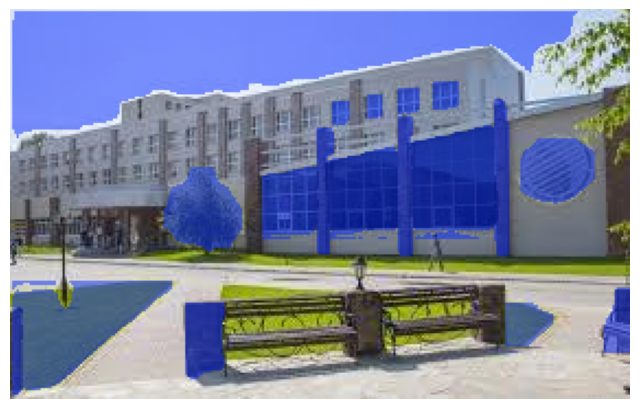

In [ ]:
#Ячейка 5: Fast SAM Everything Prompt
# Предсказание FastSAM (все объекты)
results = fs_model.predict('tgu.jpg', retina_masks=True, imgsz=512, conf=0.4)

# Используем встроенную визуализацию от Ultralytics
res_plotted = results[0].plot(conf=False, boxes=False)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


image 1/1 /content/tgu.jpg: 352x512 19 objects, 13.1ms
Speed: 2.3ms preprocess, 13.1ms inference, 3.4ms postprocess per image at shape (1, 3, 352, 512)


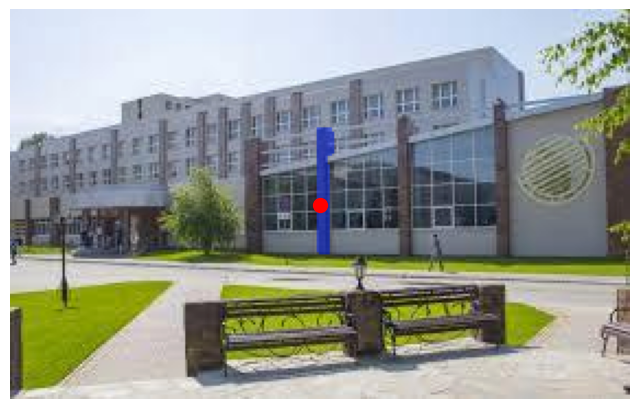

In [ ]:
#Ячейка 6: Point Prompt
from ultralytics.models.fastsam import FastSAMPredictor

# Предсказание FastSAM
results = fs_model.predict('tgu.jpg', retina_masks=True, imgsz=512, conf=0.4)

# Создаем predictor
predictor = FastSAMPredictor(overrides={'model':'FastSAM-s.pt', 'conf':0.4, 'imgsz':512})

# Точка в центре изображения
h, w = img.shape[:2]
x, y = w // 2, h // 2

annotations = predictor.prompt(results, points=[[x, y]], labels=[1])

# Встроенная визуализация
res_plotted = annotations[0].plot(conf=False, boxes=False)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.scatter([x], [y], c='red', s=100)
plt.axis('off')
plt.show()

In [ ]:
# Устанавливаем CLIP (если ещё не установлен)
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_20zucx_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_20zucx_
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=b11839569f3e642be3eef203ea1c811f8fdfb4b35965a86788a48740573b33f2
  Stored in directory: /tmp/pip-ephem-wheel-cache-ht8dutjn/wheels/3f/7c/a4/9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip



image 1/1 /content/tgu.jpg: 352x512 19 objects, 12.8ms
Speed: 2.1ms preprocess, 12.8ms inference, 3.0ms postprocess per image at shape (1, 3, 352, 512)


100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 47.9MiB/s]


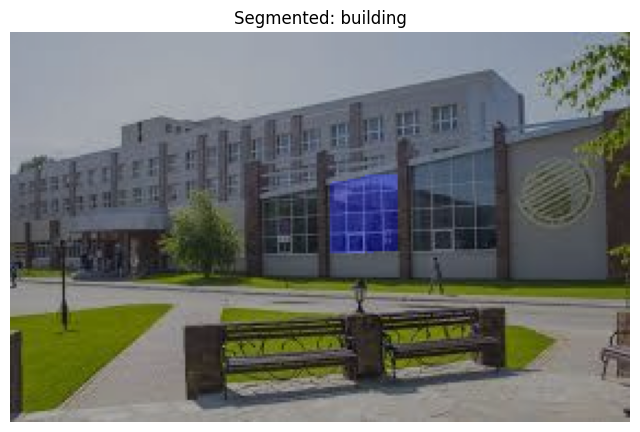

In [ ]:
#Ячейка 7: Text Propmpt

import clip
import torch
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Предсказание FastSAM
results = fs_model.predict('tgu.jpg', retina_masks=True, imgsz=512, conf=0.4)[0]

# Загружаем CLIP
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# Текстовая подсказка
prompt = 'building'
text = clip.tokenize([prompt]).to(device)

# Открываем изображение
image = Image.open('tgu.jpg').convert('RGB')
original_img = np.array(image)

# Вычисляем сходство каждой маски с текстом
mask_scores = []
for mask in results.masks.data:
    mask_np = mask.cpu().numpy()
    mask_img = Image.fromarray((mask_np * 255).astype(np.uint8)).resize(image.size)
    masked_img = Image.composite(image, Image.new('RGB', image.size), mask_img)

    image_input = preprocess(masked_img).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
        text_features = clip_model.encode_text(text)
        similarity = torch.cosine_similarity(image_features, text_features)
        mask_scores.append(similarity.item())

best_idx = np.argmax(mask_scores)

# Простая и надежная визуализация
final_mask = results.masks.data[best_idx].cpu().numpy()
colored_mask = np.zeros_like(original_img)
colored_mask[:, :, 2] = (final_mask * 255).astype(np.uint8)  # красный канал

blended = cv2.addWeighted(original_img, 0.7, colored_mask, 0.3, 0)

# Визуализация
plt.figure(figsize=(8,8))
plt.imshow(blended)
plt.axis('off')
plt.title(f'Segmented: {prompt}')
plt.show()
